# Follow up experimental design development

By reanalysing the data from Ott et al., we've found that participants behaviour is best explained by a model combining a forward planning component with a task structured preference component. Importantly, the integration of both these components occur in a Bayesian-like fashion: participants rely strongly on planning when their preferences are weak (i.e. uncertain) and vice versa. Furthermore, we've found that participants' preferences are not just arbitrary bias, they rather reflect the structure of the task in an adaptative way: following preferences only yields sub-optimal but better than completely random actions. Finally, we've observed that participants preferences look quite similar to the marginal action probability associated with each level of each features of the task under the optimal policy, suggesting that participants preferences might constitute a low dimensional projection of an approximation of the optimal policy, providing participants with a good first pass solution on the basis of which they can determine whether additional planning is needed or if they can simply follow the approximation.

The goal of the follow up experiment is to provide further support to this account and convincingly show that participants decision making reflect the integration between a forward planning component and task specific preferences. In the paper, we put forth a few predictions specific to our account:

    "The present account makes several testable predictions about when preference-based guidance should dominate. Reliance on preferences should increase when task features provide a clear action tendency, when forward planning time is limited, or when the marginal value of additional computation is low. Conversely, reliance on forward planning should increase when task features provide conflicting action tendencies, when future consequences are difficult to infer from local features alone, or when the cost of an error is high. Future experiments could test these predictions by manipulating factors such as time pressure, training, instructions, and task familiarity, planning horizon, task volatility, or the reliability of feature-based cues. Such manipulations could help disentangle the sources of task-specific preferences and clarify how structured priors are formed, adapted and integrated with forward planning. "

These are just specific ideas for new experiments, but the broad goal is to design the new experiment where the conditions are such that we would expect the strongest changes in participants reliance on planning vs. preferences according to our model. In addition, to show that participants preferences are task specific, we should show that preferences are notifiably different in the new design compared to the old one. One issue with this is that we can't derive expected preferences in a given design based on the model alone since these were fitted based on participants data. However, we have observed that their preferences are not too far off the factor-levels marginal action distribution, which they are probably bound to be if they are to be adaptive to the task (i.e. bring about okay results without much planning). So we can use these as a proxy for what the preferences are going to be.

Overall, in terms of experimental design, I think we should have two tasks conducted by the same participants, so that we can show the effect within participants: have one task where we expect low reliance on planning, the other where we expect stronger reliance on it. That way, we can test whether the model parameters change in the direction we predict, which would make provide strong support to our model. 

The simplest way to go, in line with the proposition in our paper would be to simply replicate the exact same design and modulate some external parameters:
- RT limit: Experiment 1 with RT limit of 5s, Experiment 2 with RT limit of 1s. We would predict decreased reliance on planning when participants have less time to plan
- Change bonus: experiment 1 with max bonus of say 2€, second experiment with max bonus of say 5€. We would expect participants to rely more on planning when they have more to gain from it

However, such peripheral changes to the design would not convincingly show that preferences are task specific. I would therefore go with a change to the task itself, speicfically changing the factor-levels, with the goal to modulate the expected preferences in very particular way to (1) show that preferences are truly task-specific (rather than being biases inherent from participants environment happened to be adaptive in our task) and (2) that reliance on planning depends on the preferences. So we should design the experiment so as to maximize a couple of quantities:
- The difference in expected preferences (i.e. marginal action probabilities) between the original task and the new version: provides support to the claim that preferences are task specific
- The difference in expected preferences entropy between the original task and the new version: provides support to the claim that reliance on planning depends on preference entropy
- The difference in returns between pure planning and preferences derived policies: provides support to the claim that reliance on planning depends on the marginal value of additional computations

My general idea would be to have task 1 replicating Ott et al. design and task 2 maximizing the difference in these three axes to increase model discriminability. Note that I am not closing to door to manipulating peripheral things (like RT cap and so on), these could be follow up to the follow up. In what follows, I will generate new versions of the task by manipulating each factors one at time to see what shakes. 


# Design exploration

The figures below display the marginal action probability associated with each state levels for different versions of the task. In each figure, the top row shows the probabilities for the original task from Ott et al. 2021, and the row below shows the marginal action probability for a different version of the task, but only for the factor levels that the two tasks have in common. The x-axis shows each factor level and the y-axis shows the marginal action probability of accepting the offer. In the title, the mean diff is the mean absolute difference between the probabilities in the original and new task. 

I further calculated the average "combinatorial" entropy associated with each task: for each possible state of a task, I apply expit to each factor-level marginal action probability, sum across states, convert back to probability space using sigmoid, calculate the entropy, and average across all possible states. This is to be as close as possible to our model. In other words:

$$
\mu_{H(s)} = \frac{1}{N}\sum_{s=0}^{N} H(s)
$$

Where:

$$
H(s) = \sigma(\eta(P(A=1|E)) + \eta(P(A=1|O)) + \eta(P(A=1|CC)) + \eta(P(A=1|FC)))
$$

Finally, the DR_new and DR_old show the difference in return between the optimal policy and preference policy, relative to the return of the optimal policy (0 means no difference between optimal and preference policy, 1 means 0 return for the preference policy). 

In [45]:
# Import all packages

# General utilities:
import os 
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import warnings
import matplotlib.colors as mcolors
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# Stats
import pymc as pm
import arviz as az
import bambi as bmb
from scipy.special import logit, expit
from scipy.stats import pearsonr

# Custom packages:
from stabst.MarkovDecisionProcess import MDP
from stabst.TaskConfig import LimitedEnergyTask
from stabst.utils import avg_reduce_mdp, abstract2ground_value


In [46]:
# Functions to calculate 

def get_marginal_proba(task):
    # Build the task:
    task.build()

    # Create full MDP and compute solution for later reference:
    gamma = 1
    task_mdp = MDP(task.states, task.tp, task.r, gamma, s2i=task.s2i)
    _, Q_full = task_mdp.backward_induction()

    # Calculate the marginal action distribution associated with each aspect of the task:
    pi_optimal = task_mdp.greedy_policy(Q_full)

    marginal_action_proba = []
    # Loop through each level and each state:
    for i, factor in enumerate([task.E, task.O, task.C, task.C]):
        for lvl in factor:
            p_a = []
            for ii, state in enumerate(task.states):
                if state[i] == lvl:
                    p_a.append(pi_optimal[ii])
            # Average:
            marginal_action_proba.append(np.mean(p_a))
    return marginal_action_proba

def return_plan_pref(task):
    # This function calculates the returns of a policy derived from pure forward planning vs. preference only:

    # Calculate marginal action proba:
    marginal_action_proba = get_marginal_proba(task)
    # Convert to a dictionary:
    # Create directory to store the marginal probability of each level for each factor:
    mp_a_dict = {fctr: {lvl: [] for lvl in lvls} for fctr, lvls in 
                zip(['e', 'o', 'cc', 'fc'], [task.E, task.O, task.C, task.C])}
    # Populate the directory:
    n = 0
    for fctr_i, fctr in enumerate(['e', 'o', 'cc', 'fc']):
        for lvl in  [task.E, task.O, task.C, task.C][fctr_i]:
            mp_a_dict[fctr][lvl] = marginal_action_proba[n]
            n += 1
    # Create full MDP and compute solution for later reference:
    gamma = 1
    task_mdp = MDP(task.states, task.tp, task.r, gamma, s2i=task.s2i)
    _, Q_full = task_mdp.backward_induction()

    # Calculate the marginal action distribution associated with each aspect of the task:
    pi_optimal = task_mdp.greedy_policy(Q_full)

    # Derive the policy from preferences:
    pi_pref = []
    for state in task_mdp.states:
        pi_pref.append(expit(logit(mp_a_dict['e'][state[0]]) + logit(mp_a_dict['o'][state[1]]) + logit(mp_a_dict['cc'][state[2]]) + logit(mp_a_dict['fc'][state[3]])))
    return task_mdp.expected_return(pi_optimal), task_mdp.expected_return(np.array([1-np.array(pi_pref), pi_pref]).T)


def plot_marginal_proba(task, marginal_action_proba, task_ori, marginal_action_proba_ori, ax=None, alpha=0.8):
    if ax is None:
        fig, ax = plt.subplots(2, sharex=True)

    # Plot original for reference:
    # Get the number of levels for each factor
    ns = [len(task_ori.E), len(task_ori.O), len(task_ori.C), len(task_ori.C)]
    factor_levels = [task_ori.E, task_ori.O, task_ori.C, task_ori.C]
    factors_names = ["e", "o", "cc", "fc"]
    ctr = 0
    poss = []
    xticks = []
    for fctr_i, n in enumerate(ns):
        pos = [i + ctr for i in range(n)]
        ax[0].bar(pos, marginal_action_proba_ori[ctr:ctr + n], alpha=alpha)
        poss += pos
        xticks += [f"{factors_names[fctr_i]}={val}" for val in factor_levels[fctr_i]]
        ctr += n
    ax[0].set_xticks([])
    ax[0].grid(linestyle=":", axis='y')

    # Plot:
    # Get the number of levels for each factor
    ns = [len(task.E), len(task.O), len(task.C), len(task.C)]
    factor_levels = [task.E, task.O, task.C, task.C]
    factors_names = ["e", "o", "cc", "fc"]
    ctr = 0
    poss = []
    xticks = []
    for fctr_i, n in enumerate(ns):
        pos = [i + ctr for i in range(n)]
        ax[1].bar(pos, marginal_action_proba[ctr:ctr + n], alpha=alpha)
        poss += pos
        xticks += [f"{factors_names[fctr_i]}={val}" for val in factor_levels[fctr_i]]
        ctr += n
    ax[1].set_ylabel("P(A=1)")
    ax[1].set_xticks(poss)
    ax[1].set_xticklabels(xticks, rotation=30)
    ax[1].set_ylabel("P(A=1)");
    plt.grid(linestyle=":", axis='y')


    fig.subplots_adjust(hspace=0)
    ax[0].set_ylim([0, 1])
    ax[1].set_ylim([0, 1])
    return ax

def marginal_proba_diff(task, marginal_action_proba, 
                        task_ori, marginal_action_proba_ori):
    # This function calculates the discrepancy in marginal action distribution
    # for the states that are common between the new and original design:
    
    # List factor levels in original task:
    fctr_names = ['e', 'o', 'cc', 'fc']
    fctr_nested_ori = [task_ori.E, task_ori.O, task_ori.C, task_ori.C]
    fctr_nested = [task.E, task.O, task.C, task.C]
    lvl_dict_ori = {fctr: lvls for fctr, lvls in 
                    zip(fctr_names, fctr_nested_ori)}
    lvl_dict = {fctr: lvls for fctr, lvls in 
                    zip(fctr_names, fctr_nested)}
    
    fctr_lvl_ori = [[f'{fctr}={lvl}' for lvl in lvl_dict_ori[fctr]] for fctr in lvl_dict_ori.keys()]
    fctr_lvl_new = [[f'{fctr}={lvl}' for lvl in lvl_dict[fctr]] for fctr in lvl_dict.keys()]

    # Flatten the lists:
    fctr_lvl_ori = [val for ls in fctr_lvl_ori for val in ls]
    fctr_lvl_new = [val for ls in fctr_lvl_new for val in ls]

    # Loop through each original level:
    diff_ttl = 0
    n = 0
    for i, lvl in enumerate(fctr_lvl_ori):
        # Check whether this exists in the new task:
        if not lvl in fctr_lvl_new:
            continue
        # Get the marginal action proba:
        pa_ori = marginal_action_proba_ori[i]
        # Get the marginal action proba in the new task
        pa_new = marginal_action_proba[fctr_lvl_new.index(lvl)]
        # Compute the squared difference:
        diff = np.abs(pa_ori - pa_new)
        diff_ttl += diff
        n += 1
    return diff_ttl, diff_ttl/n

def entropy(p):
    if p == 0:
        p += 0.000001
    elif p == 1:
        p -= 0.000001
    return (-p * np.log(p) - (1-p) * np.log(1 - p)) / (-0.5 * np.log(0.5) - (1-0.5) * np.log(1 - 0.5))


def marginal_proba_entropy(task, marginal_action_proba):

    # Combine factors into list of list:
    fctr_nested = [task.E, task.O, task.C, task.C]
    # Create directory to store the marginal probability of each level for each factor:
    mp_a_dict = {fctr: [] for fctr, lvls in 
                zip(['e', 'o', 'cc', 'fc'], fctr_nested)}
    # Populate the directory:
    n = 0
    for fctr_i, fctr in enumerate(['e', 'o', 'cc', 'fc']):
        for lvl in fctr_nested[fctr_i]:
            mp_a_dict[fctr].append(marginal_action_proba[n])
            n += 1
    # Loop through each factors to combine marginal action probability of each state:
    state_entropy = []
    # Compute combinations:
    for p_e in mp_a_dict["e"]:
        for p_o in mp_a_dict["o"]:
            for p_cc in mp_a_dict["cc"]:
                for p_fc in mp_a_dict["fc"]:
                    # Convert each to logit space:
                    score = logit(p_e) + logit(p_o) + logit(p_cc) + logit(p_fc)
                    # Back to proba:
                    p_score = expit(score)
                    # Entropy:
                    state_entropy.append(entropy(p_score))

    return np.mean(state_entropy)

# Play around with energy:

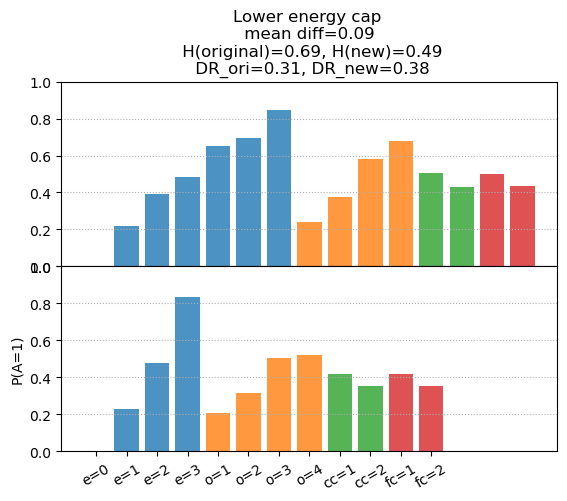

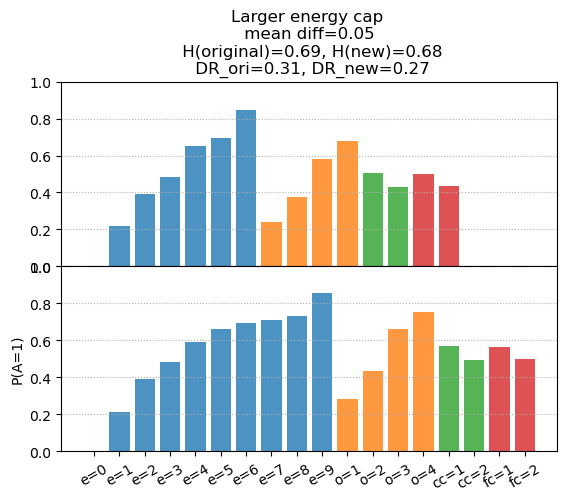

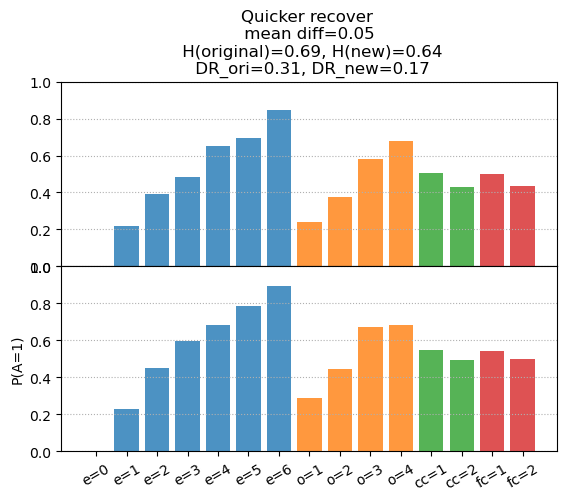

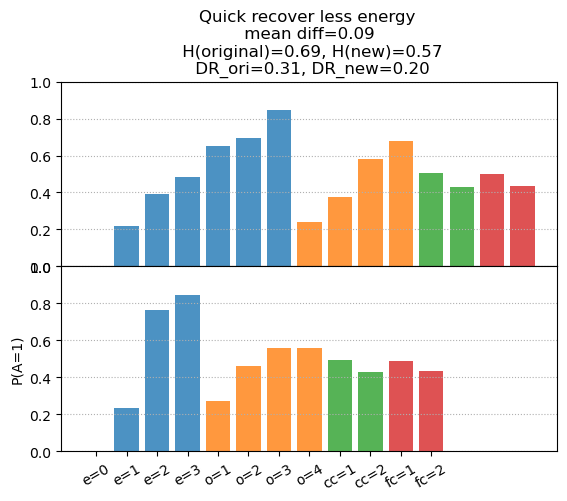

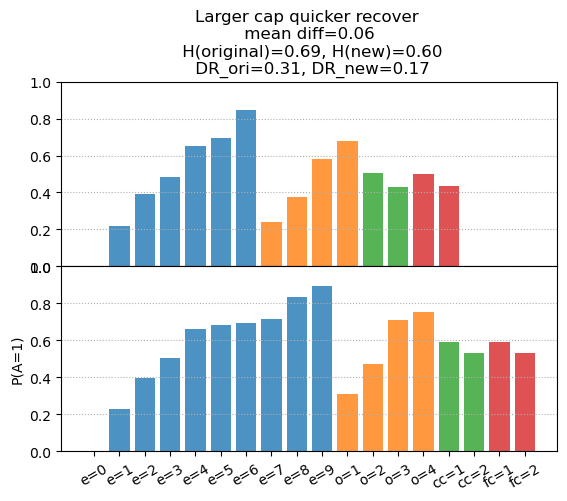

In [47]:
# Original task:
# ===============================================================
task_ori = LimitedEnergyTask(O=[1, 2, 3, 4], p_offer=[1/4] * 4)
marginal_action_proba_ori = get_marginal_proba(task_ori)

# Lower energy cap
# ===============================================================
task_new = LimitedEnergyTask(O=[1, 2, 3, 4], p_offer=[1/4] * 4, 
                                      max_energy=3)
marginal_action_proba = get_marginal_proba(task_new)
# Plot the marginal action probability:
ax = plot_marginal_proba(task_new, marginal_action_proba, 
                         task_ori, marginal_action_proba_ori)
# Calculate the squared difference:
diff_ttl, diff_avg = marginal_proba_diff(task_new, marginal_action_proba, 
                    task_ori, marginal_action_proba_ori)
entropy_orig = marginal_proba_entropy(task_ori, marginal_action_proba_ori)
entropy_new = marginal_proba_entropy(task_new, marginal_action_proba)
# Compute the preference and planning returns:
r_planning_ori, r_pref_ori = return_plan_pref(task_ori)
r_planning_new, r_pref_new = return_plan_pref(task_new)
ax[0].set_title(f"Lower energy cap \n mean diff={diff_avg:.2f} "
                f"\n H(original)={entropy_orig:.2f}, H(new)={entropy_new:.2f}"
                f"\n DR_ori={(r_planning_ori-r_pref_ori)/r_planning_ori:.2f}, DR_new={(r_planning_new-r_pref_new)/r_planning_new:.2f}");


# Larger energy cap
# ===============================================================
task_new = LimitedEnergyTask(O=[1, 2, 3, 4], p_offer=[1/4] * 4, 
                                      max_energy=9)
marginal_action_proba = get_marginal_proba(task_new)
# Plot the marginal action probability:
ax = plot_marginal_proba(task_new, marginal_action_proba, 
                         task_ori, marginal_action_proba_ori)
# Calculate the squared difference:
diff_ttl, diff_avg = marginal_proba_diff(task_new, marginal_action_proba, 
                    task_ori, marginal_action_proba_ori)
entropy_orig = marginal_proba_entropy(task_ori, marginal_action_proba_ori)
entropy_new = marginal_proba_entropy(task_new, marginal_action_proba)
# Compute the preference and planning returns:
r_planning_ori, r_pref_ori = return_plan_pref(task_ori)
r_planning_new, r_pref_new = return_plan_pref(task_new)
ax[0].set_title(f"Larger energy cap \n mean diff={diff_avg:.2f} "
                f"\n H(original)={entropy_orig:.2f}, H(new)={entropy_new:.2f}"
                f"\n DR_ori={(r_planning_ori-r_pref_ori)/r_planning_ori:.2f}, DR_new={(r_planning_new-r_pref_new)/r_planning_new:.2f}");



# Quicker energy recovery:
# ===============================================================
task_new = LimitedEnergyTask(O=[1, 2, 3, 4], p_offer=[1/4] * 4, 
                                      E_gain=2)
marginal_action_proba = get_marginal_proba(task_new)
# Plot the marginal action probability:
ax = plot_marginal_proba(task_new, marginal_action_proba, 
                         task_ori, marginal_action_proba_ori)
# Calculate the squared difference:
diff_ttl, diff_avg = marginal_proba_diff(task_new, marginal_action_proba, 
                    task_ori, marginal_action_proba_ori)
entropy_orig = marginal_proba_entropy(task_ori, marginal_action_proba_ori)
entropy_new = marginal_proba_entropy(task_new, marginal_action_proba)
# Compute the preference and planning returns:
r_planning_ori, r_pref_ori = return_plan_pref(task_ori)
r_planning_new, r_pref_new = return_plan_pref(task_new)
ax[0].set_title(f"Quicker recover \n mean diff={diff_avg:.2f} "
                f"\n H(original)={entropy_orig:.2f}, H(new)={entropy_new:.2f}"
                f"\n DR_ori={(r_planning_ori-r_pref_ori)/r_planning_ori:.2f}, DR_new={(r_planning_new-r_pref_new)/r_planning_new:.2f}");


# Quicker energy recovery and lower energy cap:
# ===============================================================
task_new = LimitedEnergyTask(O=[1, 2, 3, 4], p_offer=[1/4] * 4, 
                                      E_gain=2, max_energy=3)
marginal_action_proba = get_marginal_proba(task_new)
# Plot the marginal action probability:
ax = plot_marginal_proba(task_new, marginal_action_proba, 
                         task_ori, marginal_action_proba_ori)
# Calculate the squared difference:
diff_ttl, diff_avg = marginal_proba_diff(task_new, marginal_action_proba, 
                    task_ori, marginal_action_proba_ori)
entropy_orig = marginal_proba_entropy(task_ori, marginal_action_proba_ori)
entropy_new = marginal_proba_entropy(task_new, marginal_action_proba)
# Compute the preference and planning returns:
r_planning_ori, r_pref_ori = return_plan_pref(task_ori)
r_planning_new, r_pref_new = return_plan_pref(task_new)
ax[0].set_title(f"Quick recover less energy \n mean diff={diff_avg:.2f} "
                f"\n H(original)={entropy_orig:.2f}, H(new)={entropy_new:.2f}"
                f"\n DR_ori={(r_planning_ori-r_pref_ori)/r_planning_ori:.2f}, DR_new={(r_planning_new-r_pref_new)/r_planning_new:.2f}");


# Quicker energy recovery and larger energy cap:
# ===============================================================
task_new = LimitedEnergyTask(O=[1, 2, 3, 4], p_offer=[1/4] * 4, 
                                      E_gain=2, max_energy=9)
marginal_action_proba = get_marginal_proba(task_new)
# Plot the marginal action probability:
ax = plot_marginal_proba(task_new, marginal_action_proba, 
                         task_ori, marginal_action_proba_ori)
# Calculate the squared difference:
diff_ttl, diff_avg = marginal_proba_diff(task_new, marginal_action_proba, 
                    task_ori, marginal_action_proba_ori)
entropy_orig = marginal_proba_entropy(task_ori, marginal_action_proba_ori)
entropy_new = marginal_proba_entropy(task_new, marginal_action_proba)
# Compute the preference and planning returns:
r_planning_ori, r_pref_ori = return_plan_pref(task_ori)
r_planning_new, r_pref_new = return_plan_pref(task_new)
ax[0].set_title(f"Larger cap quicker recover \n mean diff={diff_avg:.2f} "
                f"\n H(original)={entropy_orig:.2f}, H(new)={entropy_new:.2f}"
                f"\n DR_ori={(r_planning_ori-r_pref_ori)/r_planning_ori:.2f}, DR_new={(r_planning_new-r_pref_new)/r_planning_new:.2f}");


The adjustments in the figure are as follows:
- Lower energy cap: reduce max energy from 6 to 3
- Larger energy cap: increase max energy from 6 to 9
- Quicker energy recovery: rejecting offer gains 2 instead of 1 energy
- The two last are combiations of quicker energy recovery and higher or lower energy cap

What we can see across all figures is that manipulating energy doesn't lead to any changes in the overall trends: probabilities of accepting increase with energy and offers, and decrease with increased costs. This will be true for any modifications we will do based on the structure of the task (we will never reverse the trned of the marginal likelihood increasing as a function of offer for example). 

More importantly, the modulation of energy do not lead to large differences in probabilities, as the average difference is max 0.09. The same is true in terms of entropy. In both cases, the largest difference is observed when we decrease the energy cap, because it has essentially the same effect as increasing the costs, which means across the board, participants should accept less. This explains the decrease in entropy: most marginal probas are below 0.5, which means that it is often the case that the preferences associated with each factor level point in the same direction: generally tend to reject the offer. 

In terms of difference of returns, the differences are also not that large to the first experiment, which further indicates that modifying the energy levels isn't the most fruitful approach. 

# Playing around with costs:

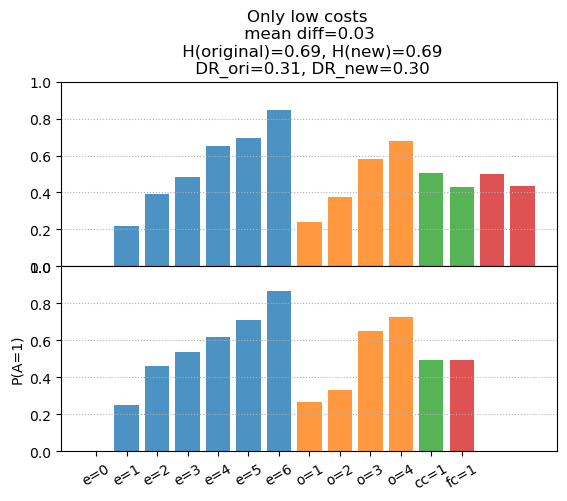

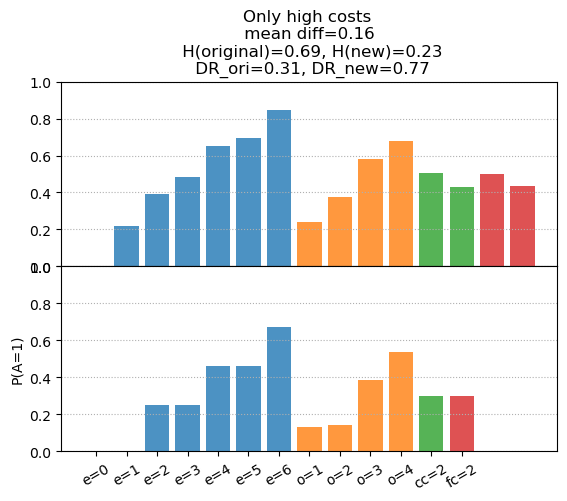

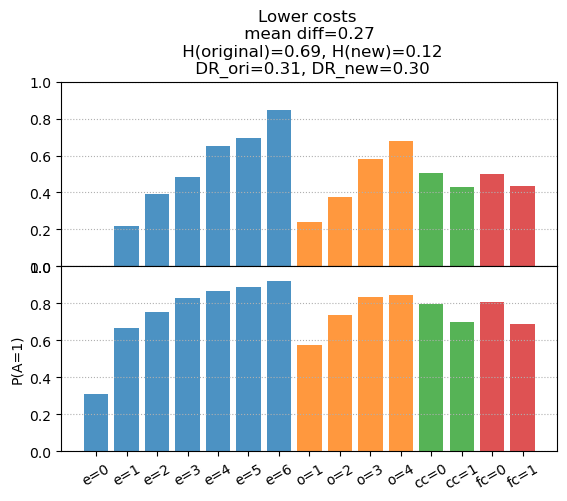

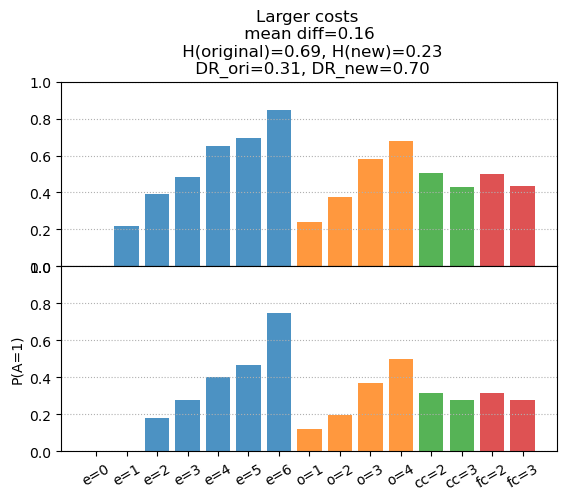

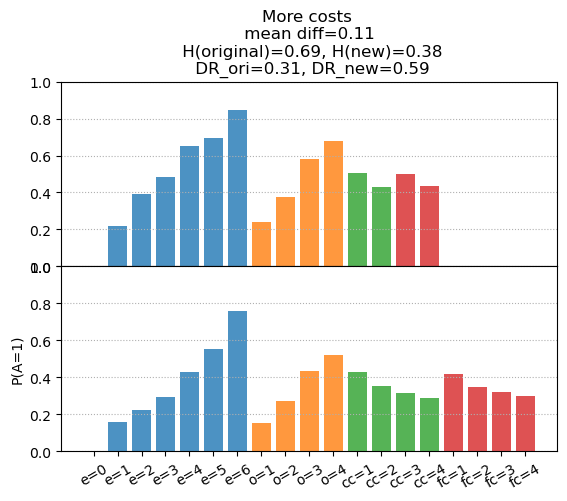

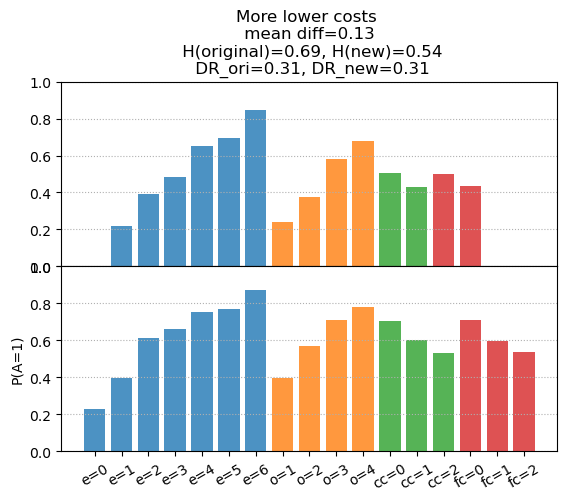

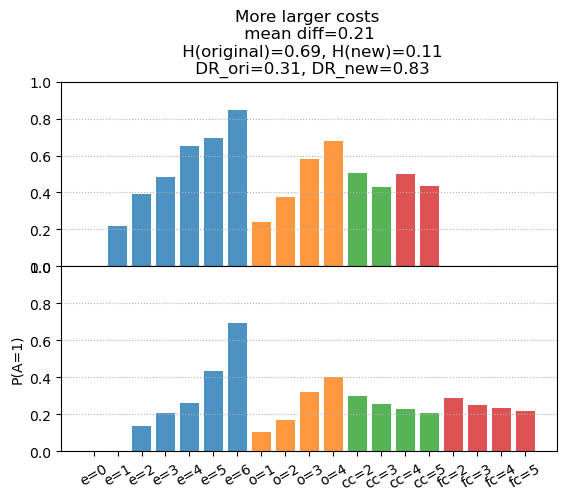

In [48]:
# Original task:
# ===============================================================
task_ori = LimitedEnergyTask(O=[1, 2, 3, 4], p_offer=[1/4] * 4)
marginal_action_proba_ori = get_marginal_proba(task_ori)

# Only low cost
# ===============================================================
task_new = LimitedEnergyTask(O=[1, 2, 3, 4], p_offer=[1/4] * 4,
                             C=[1])
marginal_action_proba = get_marginal_proba(task_new)
# Plot the marginal action probability:
ax = plot_marginal_proba(task_new, marginal_action_proba, 
                         task_ori, marginal_action_proba_ori)
diff_ttl, diff_avg = marginal_proba_diff(task_new, marginal_action_proba, 
                    task_ori, marginal_action_proba_ori)
entropy_orig = marginal_proba_entropy(task_ori, marginal_action_proba_ori)
entropy_new = marginal_proba_entropy(task_new, marginal_action_proba)
# Compute the preference and planning returns:
r_planning_ori, r_pref_ori = return_plan_pref(task_ori)
r_planning_new, r_pref_new = return_plan_pref(task_new)
ax[0].set_title(f"Only low costs \n mean diff={diff_avg:.2f} "
                f"\n H(original)={entropy_orig:.2f}, H(new)={entropy_new:.2f}"
                f"\n DR_ori={(r_planning_ori-r_pref_ori)/r_planning_ori:.2f}, DR_new={(r_planning_new-r_pref_new)/r_planning_new:.2f}");

# Only high cost
# ===============================================================
task_new = LimitedEnergyTask(O=[1, 2, 3, 4], p_offer=[1/4] * 4,
                             C=[2])
marginal_action_proba = get_marginal_proba(task_new)
# Plot the marginal action probability:
ax = plot_marginal_proba(task_new, marginal_action_proba, 
                         task_ori, marginal_action_proba_ori)
diff_ttl, diff_avg = marginal_proba_diff(task_new, marginal_action_proba, 
                    task_ori, marginal_action_proba_ori)
entropy_orig = marginal_proba_entropy(task_ori, marginal_action_proba_ori)
entropy_new = marginal_proba_entropy(task_new, marginal_action_proba)
# Compute the preference and planning returns:
r_planning_ori, r_pref_ori = return_plan_pref(task_ori)
r_planning_new, r_pref_new = return_plan_pref(task_new)
ax[0].set_title(f"Only high costs \n mean diff={diff_avg:.2f} "
                f"\n H(original)={entropy_orig:.2f}, H(new)={entropy_new:.2f}"
                f"\n DR_ori={(r_planning_ori-r_pref_ori)/r_planning_ori:.2f}, DR_new={(r_planning_new-r_pref_new)/r_planning_new:.2f}");

# Lower costs
# ===============================================================
task_new = LimitedEnergyTask(O=[1, 2, 3, 4], p_offer=[1/4] * 4,
                             C=[0, 1])
marginal_action_proba = get_marginal_proba(task_new)
# Plot the marginal action probability:
ax = plot_marginal_proba(task_new, marginal_action_proba, 
                         task_ori, marginal_action_proba_ori)
diff_ttl, diff_avg = marginal_proba_diff(task_new, marginal_action_proba, 
                    task_ori, marginal_action_proba_ori)
entropy_orig = marginal_proba_entropy(task_ori, marginal_action_proba_ori)
entropy_new = marginal_proba_entropy(task_new, marginal_action_proba)
# Compute the preference and planning returns:
r_planning_ori, r_pref_ori = return_plan_pref(task_ori)
r_planning_new, r_pref_new = return_plan_pref(task_new)
ax[0].set_title(f"Lower costs \n mean diff={diff_avg:.2f} "
                f"\n H(original)={entropy_orig:.2f}, H(new)={entropy_new:.2f}"
                f"\n DR_ori={(r_planning_ori-r_pref_ori)/r_planning_ori:.2f}, DR_new={(r_planning_new-r_pref_new)/r_planning_new:.2f}");

# Larger costs
# ===============================================================
task_new = LimitedEnergyTask(O=[1, 2, 3, 4], p_offer=[1/4] * 4,
                             C=[2, 3])
marginal_action_proba = get_marginal_proba(task_new)
# Plot the marginal action probability:
ax = plot_marginal_proba(task_new, marginal_action_proba, 
                         task_ori, marginal_action_proba_ori)
diff_ttl, diff_avg = marginal_proba_diff(task_new, marginal_action_proba, 
                    task_ori, marginal_action_proba_ori)
entropy_orig = marginal_proba_entropy(task_ori, marginal_action_proba_ori)
entropy_new = marginal_proba_entropy(task_new, marginal_action_proba)
# Compute the preference and planning returns:
r_planning_ori, r_pref_ori = return_plan_pref(task_ori)
r_planning_new, r_pref_new = return_plan_pref(task_new)
ax[0].set_title(f"Larger costs \n mean diff={diff_avg:.2f} "
                f"\n H(original)={entropy_orig:.2f}, H(new)={entropy_new:.2f}"
                f"\n DR_ori={(r_planning_ori-r_pref_ori)/r_planning_ori:.2f}, DR_new={(r_planning_new-r_pref_new)/r_planning_new:.2f}");


# More costs
# ===============================================================
task_new = LimitedEnergyTask(O=[1, 2, 3, 4], p_offer=[1/4] * 4,
                             C=[1, 2, 3, 4])
marginal_action_proba = get_marginal_proba(task_new)
# Plot the marginal action probability:
ax = plot_marginal_proba(task_new, marginal_action_proba, 
                         task_ori, marginal_action_proba_ori)
diff_ttl, diff_avg = marginal_proba_diff(task_new, marginal_action_proba, 
                    task_ori, marginal_action_proba_ori)
entropy_orig = marginal_proba_entropy(task_ori, marginal_action_proba_ori)
entropy_new = marginal_proba_entropy(task_new, marginal_action_proba)
# Compute the preference and planning returns:
r_planning_ori, r_pref_ori = return_plan_pref(task_ori)
r_planning_new, r_pref_new = return_plan_pref(task_new)
ax[0].set_title(f"More costs \n mean diff={diff_avg:.2f} "
                f"\n H(original)={entropy_orig:.2f}, H(new)={entropy_new:.2f}"
                f"\n DR_ori={(r_planning_ori-r_pref_ori)/r_planning_ori:.2f}, DR_new={(r_planning_new-r_pref_new)/r_planning_new:.2f}");

# More lower costs
# ===============================================================
task_new = LimitedEnergyTask(O=[1, 2, 3, 4], p_offer=[1/4] * 4,
                             C=[0, 1, 2])
marginal_action_proba = get_marginal_proba(task_new)
# Plot the marginal action probability:
ax = plot_marginal_proba(task_new, marginal_action_proba, 
                         task_ori, marginal_action_proba_ori)
diff_ttl, diff_avg = marginal_proba_diff(task_new, marginal_action_proba, 
                    task_ori, marginal_action_proba_ori)
entropy_orig = marginal_proba_entropy(task_ori, marginal_action_proba_ori)
entropy_new = marginal_proba_entropy(task_new, marginal_action_proba)
# Compute the preference and planning returns:
r_planning_ori, r_pref_ori = return_plan_pref(task_ori)
r_planning_new, r_pref_new = return_plan_pref(task_new)
ax[0].set_title(f"More lower costs \n mean diff={diff_avg:.2f} "
                f"\n H(original)={entropy_orig:.2f}, H(new)={entropy_new:.2f}"
                f"\n DR_ori={(r_planning_ori-r_pref_ori)/r_planning_ori:.2f}, DR_new={(r_planning_new-r_pref_new)/r_planning_new:.2f}");


# More larger costs
# ===============================================================
task_new = LimitedEnergyTask(O=[1, 2, 3, 4], p_offer=[1/4] * 4,
                             C=[2, 3, 4, 5])
marginal_action_proba = get_marginal_proba(task_new)
# Plot the marginal action probability:
ax = plot_marginal_proba(task_new, marginal_action_proba, 
                         task_ori, marginal_action_proba_ori)
diff_ttl, diff_avg = marginal_proba_diff(task_new, marginal_action_proba, 
                    task_ori, marginal_action_proba_ori)
entropy_orig = marginal_proba_entropy(task_ori, marginal_action_proba_ori)
entropy_new = marginal_proba_entropy(task_new, marginal_action_proba)
# Compute the preference and planning returns:
r_planning_ori, r_pref_ori = return_plan_pref(task_ori)
r_planning_new, r_pref_new = return_plan_pref(task_new)
ax[0].set_title(f"More larger costs \n mean diff={diff_avg:.2f} "
                f"\n H(original)={entropy_orig:.2f}, H(new)={entropy_new:.2f}"
                f"\n DR_ori={(r_planning_ori-r_pref_ori)/r_planning_ori:.2f}, DR_new={(r_planning_new-r_pref_new)/r_planning_new:.2f}");


The design adjustments of each figures are:
- Only low cost: remove cc and fc = 2
- Only high cost: remove cc and fc = 1
- Lower costs: remove cost of 2, add cost of 0 (accepting is free)
- Larger costs: remove cost of 1, add cost of 3
- More costs: costs can be [1, 2, 3, 4]
- More larger costs: costs can be [3, 4, 5, 6]

Modulating the costs has a much larger impact on the marginal action distribution, which makes sense as modulating the cost impacts all other factors across the board. Lowering the costs has a very strong effects, and so does adding more high costs. The former is an interesting case, because it means that some offers are free, bringing about the interesting scenario where participants may have no energy and still be able to accept an offer, in which case they must directly weight offer against potential energy gain. However, except in the case of low energy, the predicted preferences are more often than not in accordance, since the majority of action proba are above 0.5 -> accept the offer. Increasing costs has sort of a mirror effect: most predicted preferences are below 0.5, so they concur in suggesting rejection. 

However, when we look at the difference in return between the opitmal and preference policies, the increase of costs has a much stronger effect than making one of the costs 0. That is because when we increase the costs, the combined preferences systematically lead to P(A=1) < 0.5. Even when e=6, it's not enough to push against the offer and costs preferences, leading to the preferences systematically suggesting to reject the offer. But obviously, always rejecting the offer isn't good to maximize return, and the optimal policy leads to much larger returns. 

Both increasing and decreasing the costs are good alternatives with different effects to keep in mind

# Play around with offers:

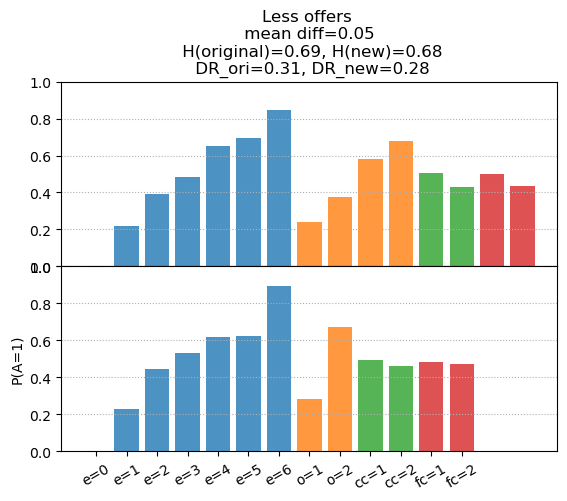

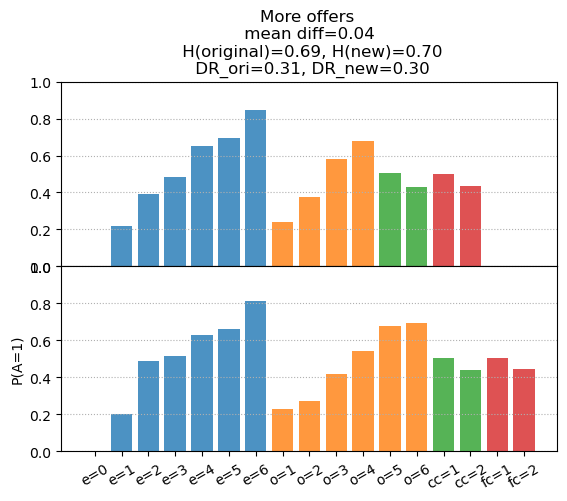

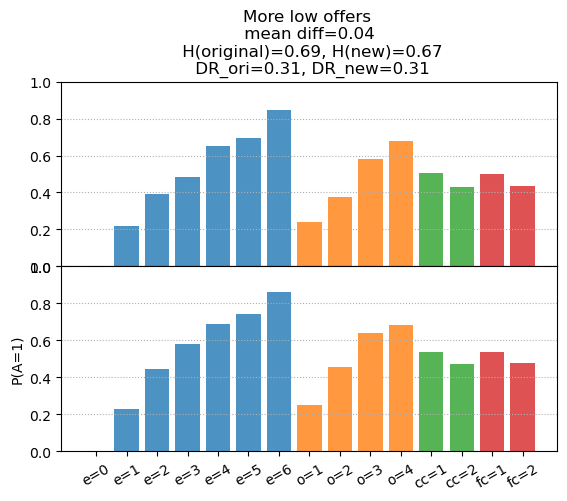

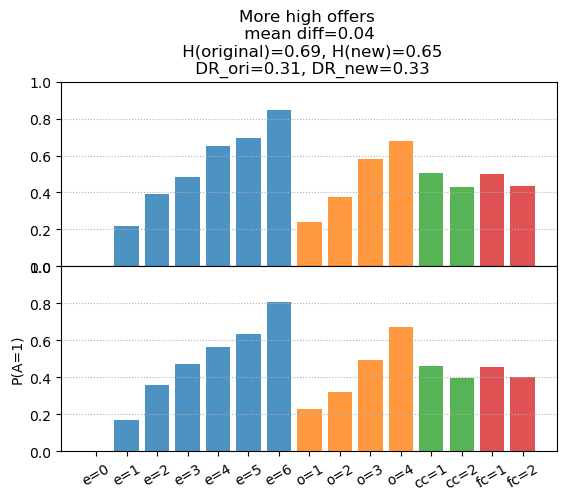

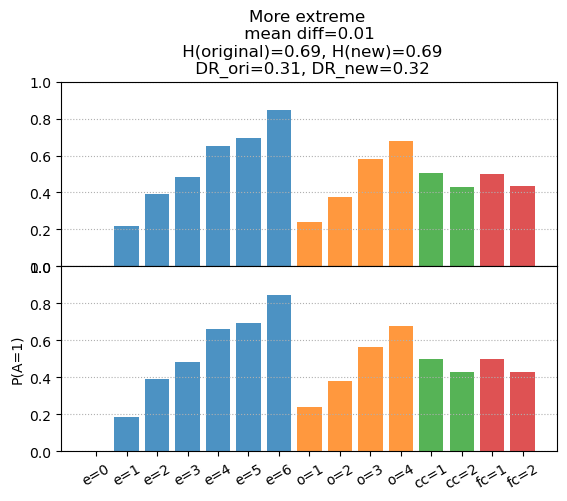

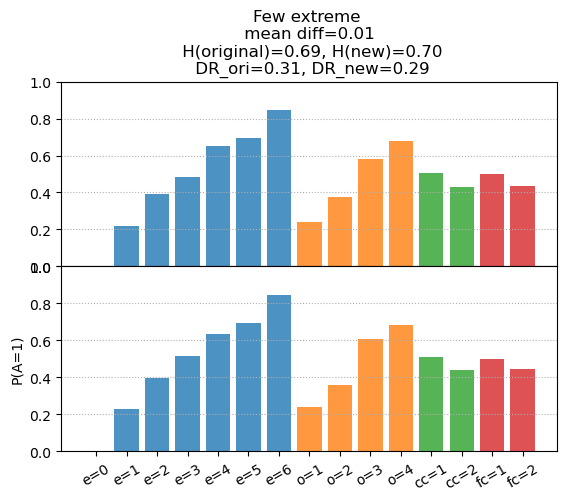

In [50]:
# Original task:
# ===============================================================
task_ori = LimitedEnergyTask(O=[1, 2, 3, 4], p_offer=[1/4] * 4)
marginal_action_proba_ori = get_marginal_proba(task_ori)

# Less offers
# ===============================================================
task_new = LimitedEnergyTask(O=[1, 2], p_offer=[1/2] * 2, )
marginal_action_proba = get_marginal_proba(task_new)
# Plot the marginal action probability:
ax = plot_marginal_proba(task_new, marginal_action_proba, 
                         task_ori, marginal_action_proba_ori)
diff_ttl, diff_avg = marginal_proba_diff(task_new, marginal_action_proba, 
                    task_ori, marginal_action_proba_ori)
entropy_orig = marginal_proba_entropy(task_ori, marginal_action_proba_ori)
entropy_new = marginal_proba_entropy(task_new, marginal_action_proba)
# Compute the preference and planning returns:
r_planning_ori, r_pref_ori = return_plan_pref(task_ori)
r_planning_new, r_pref_new = return_plan_pref(task_new)
ax[0].set_title(f"Less offers \n mean diff={diff_avg:.2f} "
                f"\n H(original)={entropy_orig:.2f}, H(new)={entropy_new:.2f}"
                f"\n DR_ori={(r_planning_ori-r_pref_ori)/r_planning_ori:.2f}, DR_new={(r_planning_new-r_pref_new)/r_planning_new:.2f}");

# More offers
# ===============================================================
task_new = LimitedEnergyTask(O=[1, 2, 3, 4, 5, 6], p_offer=[1/6] * 6, )
marginal_action_proba = get_marginal_proba(task_new)
# Plot the marginal action probability:
ax = plot_marginal_proba(task_new, marginal_action_proba, 
                         task_ori, marginal_action_proba_ori)
diff_ttl, diff_avg = marginal_proba_diff(task_new, marginal_action_proba, 
                    task_ori, marginal_action_proba_ori)
entropy_orig = marginal_proba_entropy(task_ori, marginal_action_proba_ori)
entropy_new = marginal_proba_entropy(task_new, marginal_action_proba)
# Compute the preference and planning returns:
r_planning_ori, r_pref_ori = return_plan_pref(task_ori)
r_planning_new, r_pref_new = return_plan_pref(task_new)
ax[0].set_title(f"More offers \n mean diff={diff_avg:.2f} "
                f"\n H(original)={entropy_orig:.2f}, H(new)={entropy_new:.2f}"
                f"\n DR_ori={(r_planning_ori-r_pref_ori)/r_planning_ori:.2f}, DR_new={(r_planning_new-r_pref_new)/r_planning_new:.2f}");

# Fewer large offers:
# ===============================================================
task_new = LimitedEnergyTask(O=[1, 2, 3, 4], p_offer=[0.4, 0.4, 0.1, 0.1], )
marginal_action_proba = get_marginal_proba(task_new)
# Plot the marginal action probability:
ax = plot_marginal_proba(task_new, marginal_action_proba, 
                         task_ori, marginal_action_proba_ori)
diff_ttl, diff_avg = marginal_proba_diff(task_new, marginal_action_proba, 
                    task_ori, marginal_action_proba_ori)
entropy_orig = marginal_proba_entropy(task_ori, marginal_action_proba_ori)
entropy_new = marginal_proba_entropy(task_new, marginal_action_proba)
# Compute the preference and planning returns:
r_planning_ori, r_pref_ori = return_plan_pref(task_ori)
r_planning_new, r_pref_new = return_plan_pref(task_new)
ax[0].set_title(f"More low offers \n mean diff={diff_avg:.2f} "
                f"\n H(original)={entropy_orig:.2f}, H(new)={entropy_new:.2f}"
                f"\n DR_ori={(r_planning_ori-r_pref_ori)/r_planning_ori:.2f}, DR_new={(r_planning_new-r_pref_new)/r_planning_new:.2f}");

# Fewer low offers:
# ===============================================================
task_new = LimitedEnergyTask(O=[1, 2, 3, 4], p_offer=[0.1, 0.1, 0.4, 0.4], )
marginal_action_proba = get_marginal_proba(task_new)
# Plot the marginal action probability:
ax = plot_marginal_proba(task_new, marginal_action_proba, 
                         task_ori, marginal_action_proba_ori)
diff_ttl, diff_avg = marginal_proba_diff(task_new, marginal_action_proba, 
                    task_ori, marginal_action_proba_ori)
entropy_orig = marginal_proba_entropy(task_ori, marginal_action_proba_ori)
entropy_new = marginal_proba_entropy(task_new, marginal_action_proba)
# Compute the preference and planning returns:
r_planning_ori, r_pref_ori = return_plan_pref(task_ori)
r_planning_new, r_pref_new = return_plan_pref(task_new)
ax[0].set_title(f"More high offers \n mean diff={diff_avg:.2f} "
                f"\n H(original)={entropy_orig:.2f}, H(new)={entropy_new:.2f}"
                f"\n DR_ori={(r_planning_ori-r_pref_ori)/r_planning_ori:.2f}, DR_new={(r_planning_new-r_pref_new)/r_planning_new:.2f}");

# Fewer extreme offers:
# ===============================================================
task_new = LimitedEnergyTask(O=[1, 2, 3, 4], p_offer=[0.4, 0.1, 0.1, 0.4], )
marginal_action_proba = get_marginal_proba(task_new)
# Plot the marginal action probability:
ax = plot_marginal_proba(task_new, marginal_action_proba, 
                         task_ori, marginal_action_proba_ori)
diff_ttl, diff_avg = marginal_proba_diff(task_new, marginal_action_proba, 
                    task_ori, marginal_action_proba_ori)
entropy_orig = marginal_proba_entropy(task_ori, marginal_action_proba_ori)
entropy_new = marginal_proba_entropy(task_new, marginal_action_proba)
# Compute the preference and planning returns:
r_planning_ori, r_pref_ori = return_plan_pref(task_ori)
r_planning_new, r_pref_new = return_plan_pref(task_new)
ax[0].set_title(f"More extreme \n mean diff={diff_avg:.2f} "
                f"\n H(original)={entropy_orig:.2f}, H(new)={entropy_new:.2f}"
                f"\n DR_ori={(r_planning_ori-r_pref_ori)/r_planning_ori:.2f}, DR_new={(r_planning_new-r_pref_new)/r_planning_new:.2f}");

# More extreme offers:
# ===============================================================
task_new = LimitedEnergyTask(O=[1, 2, 3, 4], p_offer=[0.1, 0.4, 0.4, 0.1], )
marginal_action_proba = get_marginal_proba(task_new)
# Plot the marginal action probability:
ax = plot_marginal_proba(task_new, marginal_action_proba, 
                         task_ori, marginal_action_proba_ori)
diff_ttl, diff_avg = marginal_proba_diff(task_new, marginal_action_proba, 
                    task_ori, marginal_action_proba_ori)
entropy_orig = marginal_proba_entropy(task_ori, marginal_action_proba_ori)
entropy_new = marginal_proba_entropy(task_new, marginal_action_proba)
# Compute the preference and planning returns:
r_planning_ori, r_pref_ori = return_plan_pref(task_ori)
r_planning_new, r_pref_new = return_plan_pref(task_new)
ax[0].set_title(f"Few extreme \n mean diff={diff_avg:.2f} "
                f"\n H(original)={entropy_orig:.2f}, H(new)={entropy_new:.2f}"
                f"\n DR_ori={(r_planning_ori-r_pref_ori)/r_planning_ori:.2f}, DR_new={(r_planning_new-r_pref_new)/r_planning_new:.2f}");


The design adjustments are as follows:
- Less offers: remove offer 3 and 4
- More offers: add offer 5 and 6
- Fewer large offers: proba of offer=3 or 4 = 0.1, offer=1 and 2= 0.4
- Fewer low offers: proba of offer=3 or 4 = 0.1, offer=1 and 2= 0.4
- Fewer extreme offers: proba of offer=2 and 3 = 0.1, offer=1 and 4= 0.4
- More extreme offers: proba of offer=2 and 3 = 0.4, offer=1 and 4= 0.1

Unsurprisingly, modulating offers has a really low impact overall. 

# Summary

Clearly, out of all the factors we can manipulate, costs is the most efficient at getting us where we want. We have two options there: either increase or decrease the costs. Here are the pros and cons of each:

Decreasing costs:
- pros:
    - marginal action probability very different from original task
    - preference entropy is much lower than the original task
- cons:
    - Low difference between preference and optimal policy

Increasing costs:
- pros:
    - Large difference between preference and optimal policy
    - preference entropy is lower than the original task
- cons:
    - Not as large a difference in terms of marginal action probability
    - Perhaps a boring experiment, participants rejecting in most of the trials

Which to chose is a question of what we are most interested in:
- Showing difference in the preferences themselves
- Showing a difference in the reliance of planning because of how unreliable the preferences are

I would tend to think it is better to focus on the preferences themselves this time around, because the latter is a more peripheral prediction of our model compared to the change in preferences associated with the structure of the task, and the reliance on planning depending on the preference entropy. In addition, while increasing the cost leads to changes in entropy and in difference between optimal and preferences policy, these are in the opposite direction: entropy decreases, but the loss in return when preference alone increases. Our model would predict that when preferences entropy decreases, participants should rely on them more (i.e. they are giving a clearer signal), but we also predict that when relying on preferences more leads to larger losses in returns, participants should rely more on planning. In other words, the two effects are expected to cancel each other out in terms of reliance on planning, making it difficult to give clear predictions. 

Therefore, the best design would be:
- Experiment 1: replication of the original design
- Experiment 2: change costs from 1 and 2 to 0 and 1

An alternative would be to have Experiment in be offer 0 and 1, and experiment 2 be offer 2 and 3, but that would not lead to a large difference in terms of preferences entropy. 

The specific hypothesis are the following:

H1: In Experiment 1, we will replicate the preferences weights from Ott et al.,
H2: In experiment 2, the preferences will differ from Experiment 1 (interaction between preferences and task)
H3: In experiment 2, participants will rely less on planning because their preferences are clearer (interaction between planning weight and task)
H4: In experiment 2, participants preferences will look like the marginal action probability under the optimal policy. 

If all are realized, this would provide strong support for our hypothesis, all while keeping the design very straight forward. The risks are the following:
1. Model discriminability: the change in parameters associated with such a minute change in design might be difficult
2. Having c=0 implies that there are many states where participants can simply accept (basically as long as o>1, always accept), which might make the experiment very boring, leading to disengagement (if cc= and fc=0, participants know that they can pretty much keep on pressing accept for the next 8 trials, except if o=1)

For 1, this is a question of experimental design and simulation: I will simulate data for each experiment, setting the priors for the preferences to be the marginal action distribution, and I will then test given the number of participants and trials/participants, what differences in terms of planning parameter we can detect (i.e. power analysis). 
For 2., will become clearer once I implement and maybe pilot on myself, and then on test subjects. 


# Supplementary

## Free and expansive
One other idea for manipulating costs is to have c=0 and c=2, so free and expansive:

In [ ]:
# Free expansive
# ===============================================================
task_new = LimitedEnergyTask(O=[1, 2, 3, 4], p_offer=[1/4] * 4,
                             C=[0, 2])
marginal_action_proba = get_marginal_proba(task_new)
# Plot the marginal action probability:
ax = plot_marginal_proba(task_new, marginal_action_proba, 
                         task_ori, marginal_action_proba_ori)
diff_ttl, diff_avg = marginal_proba_diff(task_new, marginal_action_proba, 
                    task_ori, marginal_action_proba_ori)
entropy_orig = marginal_proba_entropy(task_ori, marginal_action_proba_ori)
entropy_new = marginal_proba_entropy(task_new, marginal_action_proba)
# Compute the preference and planning returns:
r_planning_ori, r_pref_ori = return_plan_pref(task_ori)
r_planning_new, r_pref_new = return_plan_pref(task_new)
ax[0].set_title(f"Free & expansive \n mean diff={diff_avg:.2f} "
                f"\n H(original)={entropy_orig:.2f}, H(new)={entropy_new:.2f}"
                f"\n DR_ori={(r_planning_ori-r_pref_ori)/r_planning_ori:.2f}, DR_new={(r_planning_new-r_pref_new)/r_planning_new:.2f}");

This pattern is quite surprising, and I spent quite some time trying to figure out whether it could be a bug in my code. I haven't found anything so far. The surprising part is that the marginal action probability of the enery factor doesn't increase monotonically. Instead, when energy is 0, the probability of accepting is larger than when the energy is 1, which means that under the optimal policy, participants should more often accept than reject when their energy is depleted, but the opposite when their energy is 1. How can we explain this? 

It's all about the dynamics of the tasks and how long it takes to get energy back up. If cost is 2, it takes 2 trials to go from 0 to e=2. And so if you pass on an offer at t=8 when e=0, you gain 1 energy. If the cost in the hidden segment is 2, then you will need to wait until t=10 to have enough energy to gain an offer. So basically, that means that regardless on whether you accept or reject at t=8, you will only be able to accept a single offer in the last segment. Let's run the options for: ffc=2:

E=0 at t=8:
- e=0, t=8: reject -> e=1, t=9: reject -> e=2, t=10: accept -> e=0, t=11: reject -> e=1, t=12: reject, -> e=2, but sequence over 
- e=0, t=8: reject -> e=1, t=9: reject -> e=2, t=10: reject -> e=3, t=11: accept -> e=1, t=12: reject, -> e=2, but sequence over
In both sequences, participants can only accept offer once, regardless of what they do at t=8, so they might as well at t=8 to get two rewards. 

E=1 at t=8:
- e=1, t=8: reject -> e=2, t=9: accept -> e=0: t=10, reject -> e=1, t=11: reject -> e=2, t=12: accept -> e=0, but sequence over
- e=1, t=8: reject -> e=2, t=9: reject -> e=3: t=10, accept -> e=1, t=11: reject -> e=2, t=12: accept -> e=0, but sequence over
- e=1, t=8: accept -> e=1, t=9: reject -> e=2: t=10, accept -> e=0, t=11: reject -> e=1, t=12: reject -> e=2, but sequence over
At e=1, if they accept at t=8, they will only be able to accept one offer in the hidden segment, but if they reject at t=8, they can accept 2 offers in the hidden segments, and so the odds of getting a larger rewards than accepting o=1 at t=8 makes it worth it skipping on a free offer. 

This is an interesting finding, and shows that it is indeed possible to reverse the monotonic trend associated with energy, at least in this very particular case and might be worth considering to show that participants preferences are truly task specific, because it would be quite a remarkable finding if participants preferences were to show this kink in the distribution. 